In [2]:
library(edgeR)
library(ggplot2)
library(ggrepel)
library(EnsDb.Hsapiens.v75)
library(stringr)
library(ComplexHeatmap)
#library(clusterProfiler)
library(circlize)
library(ggrepel)
library(patchwork)
library(org.Hs.eg.db)
library(viridis)
#library(umap)

Loading required package: limma

Loading required package: ensembldb

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following object is masked from ‘package:limma’:

    plotMA


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    Filter, Find, Map, Position, Reduce, anyDuplicated, append,
    as.data.frame, basename, cbind, colnames, dirname, do.call,
    duplicated, eval, evalq, get, grep, grepl, intersect, is.unsorted,
    lapply, mapply, match, mget, order, paste, pmax, pmax.int, pmin,
    pmin.int, rank, rbind, rownames, sapply, setdiff, sort, table,
    tapply, union, unique, unsplit, which.max, which.min


Loading required package: GenomicRanges

Loading required package: stats4

Loading required package: S4Vectors


Attaching package: ‘S4Vectors’


The following objects are masked from ‘package:base’:

    I, expand.grid, unname


Loading required pac

In [3]:
count_data = read.table("raw_counts.tsv", skip = 1, header = TRUE, row.names=1)
count_data = count_data[,6:dim(count_data)[2]]
head(count_data)

,results.star.BD287_THP1_0h_rep1_Aligned.sortedByCoord.out.bam,results.star.BD287_THP1_0h_rep2_Aligned.sortedByCoord.out.bam,results.star.BD287_THP1_0h_rep3_Aligned.sortedByCoord.out.bam,results.star.BD287_THP1_0h_rep4_Aligned.sortedByCoord.out.bam,results.star.BD287_THP1_BRQ500nM_4h_rep1_Aligned.sortedByCoord.out.bam,results.star.BD287_THP1_BRQ500nM_4h_rep2_Aligned.sortedByCoord.out.bam,results.star.BD287_THP1_BRQ500nM_4h_rep3_Aligned.sortedByCoord.out.bam,results.star.BD287_THP1_BRQ500nM_4h_rep4_Aligned.sortedByCoord.out.bam,results.star.BD287_THP1_BRQ500nM_8h_rep1_Aligned.sortedByCoord.out.bam,results.star.BD287_THP1_BRQ500nM_8h_rep2_Aligned.sortedByCoord.out.bam,⋯,results.star.BD287_THP1_BRQ500nM_24h_rep3_Aligned.sortedByCoord.out.bam,results.star.BD287_THP1_BRQ500nM_24h_rep4_Aligned.sortedByCoord.out.bam,results.star.BD287_THP1_HU1mM_4h_rep1_Aligned.sortedByCoord.out.bam,results.star.BD287_THP1_HU1mM_4h_rep2_Aligned.sortedByCoord.out.bam,results.star.BD287_THP1_HU1mM_4h_rep3_Aligned.sortedByCoord.out.bam,results.star.BD287_THP1_HU1mM_4h_rep4_Aligned.sortedByCoord.out.bam,results.star.BD287_THP1_HU1mM_8h_rep1_Aligned.sortedByCoord.out.bam,results.star.BD287_THP1_HU1mM_8h_rep2_Aligned.sortedByCoord.out.bam,results.star.BD287_THP1_HU1mM_8h_rep3_Aligned.sortedByCoord.out.bam,results.star.BD287_THP1_HU1mM_8h_rep4_Aligned.sortedByCoord.out.bam
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ENSG00000223972.5,0,0,2,0,0,0,0,0,2,0.5,⋯,0,0,0,0,0,0,0,0,1.5,0
ENSG00000227232.5,1,1,2,0,0,0,1,0,1,0.5,⋯,0,1,0,0,0,0,0,2,0.5,1
ENSG00000278267.1,0,0,0,0,0,0,0,0,0,0.0,⋯,0,0,0,0,0,0,0,0,0.0,0
ENSG00000243485.5,0,0,0,0,0,0,0,0,0,0.0,⋯,0,0,0,0,0,0,0,0,0.0,0
ENSG00000284332.1,0,0,0,0,0,0,0,0,0,0.0,⋯,0,0,0,0,0,0,0,0,0.0,0
ENSG00000237613.2,0,0,0,0,0,0,0,0,0,0.0,⋯,0,0,0,0,0,0,0,0,0.0,0


In [4]:
# change colnames and rownames
colnames(count_data) = gsub("results.star.BD287_", "", gsub("_Aligned.sortedByCoord.out.bam", "", colnames(count_data)))

potential_rownames = as.character(sapply(rownames(count_data), function(x) strsplit(x, '[.]')[[1]][1]))
count_data = count_data[!(duplicated(potential_rownames)),]
rownames(count_data) = potential_rownames[!(duplicated(potential_rownames))]                           
annotations_orgDb <- AnnotationDbi::select(EnsDb.Hsapiens.v75, # database
                                     keys = rownames(count_data) ,  # data to use for retrieval
                                     columns = c("SYMBOL"), # information to retreive for given data
                                     keytype = "GENEID") # type of data given in 'keys' argument
annotations_orgDb = annotations_orgDb[!duplicated(annotations_orgDb$SYMBOL),]

count_data = count_data[annotations_orgDb$GENEID,]  # you lose a few genes here but not many
rownames(count_data) = annotations_orgDb$SYMBOL
     
head(count_data)

,THP1_0h_rep1,THP1_0h_rep2,THP1_0h_rep3,THP1_0h_rep4,THP1_BRQ500nM_4h_rep1,THP1_BRQ500nM_4h_rep2,THP1_BRQ500nM_4h_rep3,THP1_BRQ500nM_4h_rep4,THP1_BRQ500nM_8h_rep1,THP1_BRQ500nM_8h_rep2,⋯,THP1_BRQ500nM_24h_rep3,THP1_BRQ500nM_24h_rep4,THP1_HU1mM_4h_rep1,THP1_HU1mM_4h_rep2,THP1_HU1mM_4h_rep3,THP1_HU1mM_4h_rep4,THP1_HU1mM_8h_rep1,THP1_HU1mM_8h_rep2,THP1_HU1mM_8h_rep3,THP1_HU1mM_8h_rep4
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
DDX11L1,0,0,2,0,0,0,0,0,2,0.5,⋯,0,0,0,0,0,0,0,0,1.5,0
WASH7P,1,1,2,0,0,0,1,0,1,0.5,⋯,0,1,0,0,0,0,0,2,0.5,1
MIR1302-10,0,0,0,0,0,0,0,0,0,0.0,⋯,0,0,0,0,0,0,0,0,0.0,0
FAM138A,0,0,0,0,0,0,0,0,0,0.0,⋯,0,0,0,0,0,0,0,0,0.0,0
OR4G4P,0,0,0,0,0,0,0,0,0,0.0,⋯,0,0,0,0,0,0,0,0,0.0,0
OR4G11P,0,0,0,0,0,0,0,0,0,0.0,⋯,0,0,0,0,0,0,0,0,0.0,0


In [5]:
samples = read.csv("bd287_thp1_sample_sheet.csv")
head(samples)

,name,cell_line,drug,time,replicate,filename
,<chr>,<chr>,<chr>,<int>,<int>,<chr>
1,BD287_THP1_0h_rep1,thp1,DMSO,0,1,211115Van_D21-306001_NA_sequence.gz
2,BD287_THP1_0h_rep2,thp1,DMSO,0,2,211115Van_D21-306002_NA_sequence.gz
3,BD287_THP1_0h_rep3,thp1,DMSO,0,3,211115Van_D21-306003_NA_sequence.gz
4,BD287_THP1_0h_rep4,thp1,DMSO,0,4,211115Van_D21-306004_NA_sequence.gz
5,BD287_THP1_BRQ500nM_4h_rep1,thp1,BRQ_500,4,1,211115Van_D21-306005_NA_sequence.gz
6,BD287_THP1_BRQ500nM_4h_rep2,thp1,BRQ_500,4,2,211115Van_D21-306006_NA_sequence.gz


In [6]:
samples$Drug_Time = paste(samples$drug, samples$time, sep='_')
head(samples)

,name,cell_line,drug,time,replicate,filename,Drug_Time
,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>
1,BD287_THP1_0h_rep1,thp1,DMSO,0,1,211115Van_D21-306001_NA_sequence.gz,DMSO_0
2,BD287_THP1_0h_rep2,thp1,DMSO,0,2,211115Van_D21-306002_NA_sequence.gz,DMSO_0
3,BD287_THP1_0h_rep3,thp1,DMSO,0,3,211115Van_D21-306003_NA_sequence.gz,DMSO_0
4,BD287_THP1_0h_rep4,thp1,DMSO,0,4,211115Van_D21-306004_NA_sequence.gz,DMSO_0
5,BD287_THP1_BRQ500nM_4h_rep1,thp1,BRQ_500,4,1,211115Van_D21-306005_NA_sequence.gz,BRQ_500_4
6,BD287_THP1_BRQ500nM_4h_rep2,thp1,BRQ_500,4,2,211115Van_D21-306006_NA_sequence.gz,BRQ_500_4


In [7]:
conds = samples$Drug_Time
count_data = count_data[,-15]  # removing samples 8 and 14, which were empty
conds = conds[-15]

In [8]:
d0 <- DGEList(count_data)
d0 <- calcNormFactors(d0)
cutoff <- 2
drop <- which(apply(cpm(d0), 1, max) < cutoff)
d <- d0[-drop,] 
dim(d) # number of genes left

[1] 13614    23

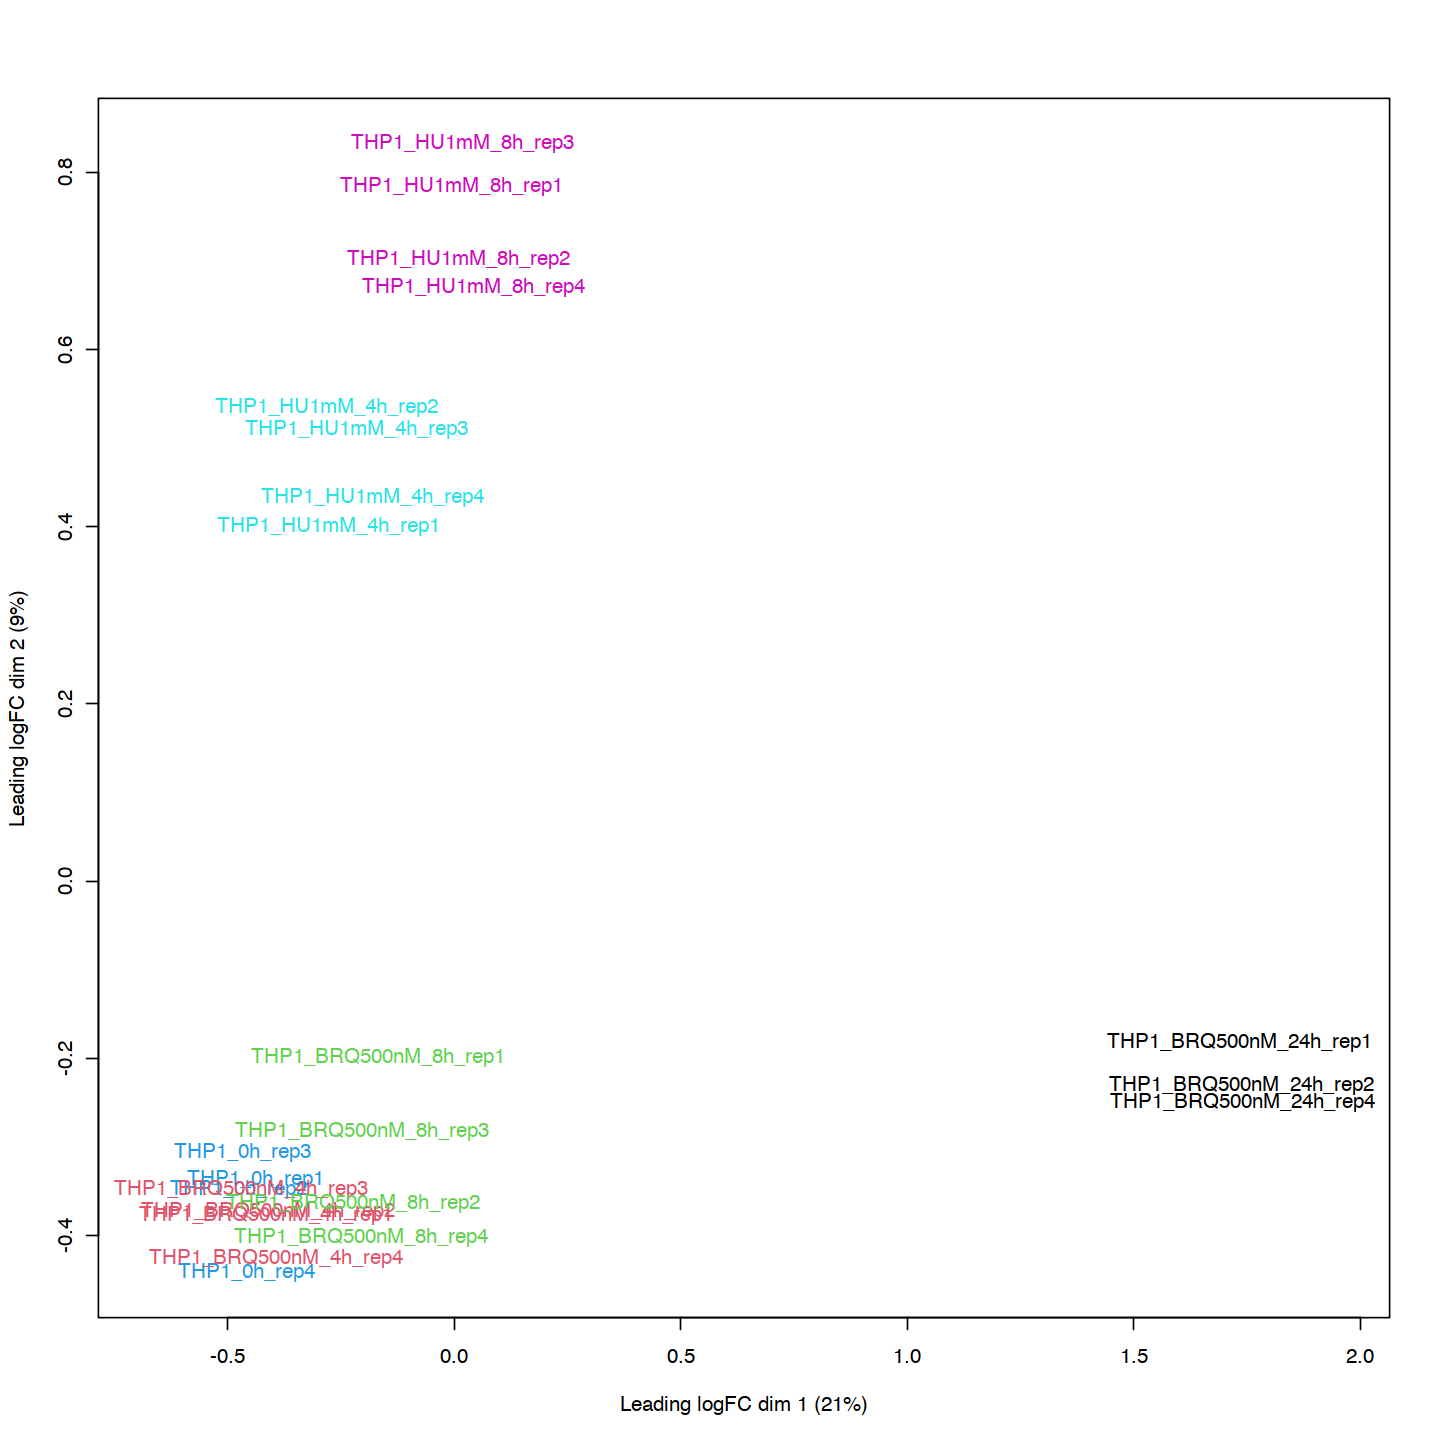

In [13]:
options(repr.plot.width=12, repr.plot.height=12)
plotMDS(d, col = as.numeric(as.factor(conds)))

,condsBRQ_500_24,condsBRQ_500_4,condsBRQ_500_8,condsDMSO_0,condsHU_1_4,condsHU_1_8
AP006222.2,1.678178,1.742948,2.125969,2.313389,1.644721,2.342192
RP5-857K21.4,4.833614,4.757234,4.454879,4.379939,4.671531,4.740358
MTND1P23,8.484484,8.759184,9.004347,8.498109,8.584755,8.823330
MTND2P28,6.659777,6.955690,6.765668,6.847367,6.914776,6.985789
hsa-mir-6723,12.291100,12.100273,12.318893,11.940144,11.972767,12.256339
RP5-857K21.7,10.317328,10.371619,10.166493,10.172466,10.503932,10.604255


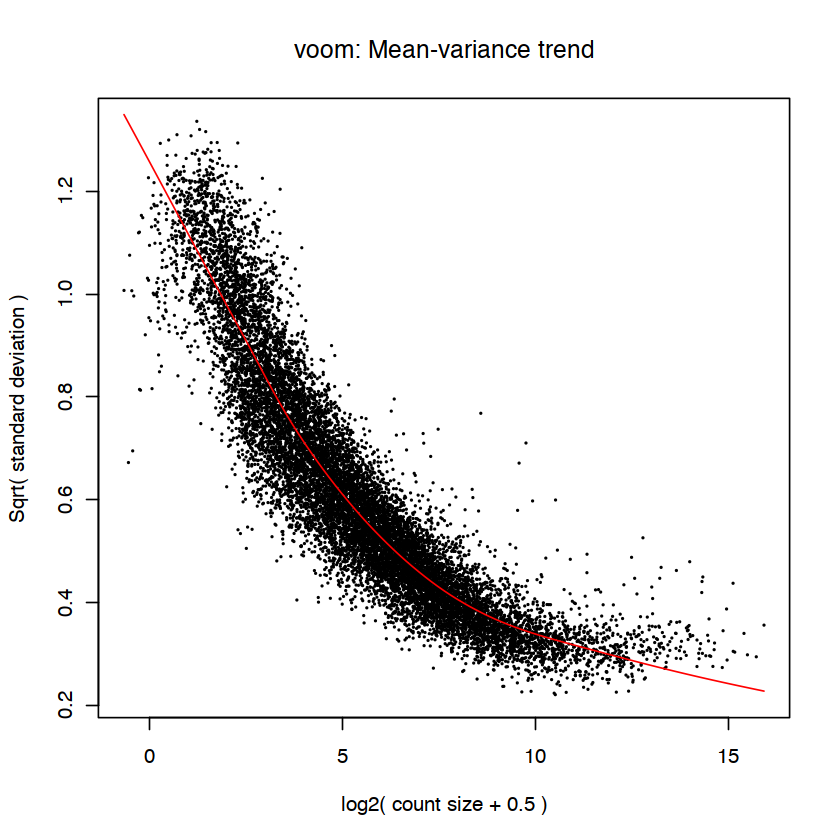

In [9]:
mm <- model.matrix(~0 + conds)
y <- voom(d, mm, plot = T)
fit <- lmFit(y, mm)
head(coef(fit))


In [10]:
norm_data = y$E
#write.csv(norm_data, "211231_BD287_THP1_norm_expr.csv", quote=F)

In [11]:
process_res = function(res, fit) {
    tmp <- contrasts.fit(fit, res)
    tmp <- eBayes(tmp)
    res <- topTable(tmp, sort.by = "P", n = Inf)
    
    res["gene"] = rownames(res)
    res["nlogpval"] = -log10(res$adj.P.Val)
    res["label"] = ""
    res_up = res[res$logFC > 0,]
    res_up[order(-res_up$t),][1:100,]$label = res_up[order(-res_up$t),][1:100,]$gene
    res_down = res[res$logFC < 0,]
    res_down[order(res_down$t),][1:100,]$label = res_down[order(res_down$t),][1:100,]$gene
    res = rbind(res_up, res_down)
    res = res[order(-res$t),]
    return(res)
}

In [12]:
brq4 <- process_res(makeContrasts(condsBRQ_500_4 - condsDMSO_0, levels = colnames(coef(fit))), fit)
brq8 <- process_res(makeContrasts(condsBRQ_500_8 - condsDMSO_0, levels = colnames(coef(fit))), fit)
brq24 <- process_res(makeContrasts(condsBRQ_500_24 - condsDMSO_0, levels = colnames(coef(fit))), fit)
hu4 <- process_res(makeContrasts(condsHU_1_4 - condsDMSO_0, levels = colnames(coef(fit))), fit)
hu8 <- process_res(makeContrasts(condsHU_1_8 - condsDMSO_0, levels = colnames(coef(fit))), fit)

Warning message:
"ggrepel: 136 unlabeled data points (too many overlaps). Consider increasing max.overlaps"


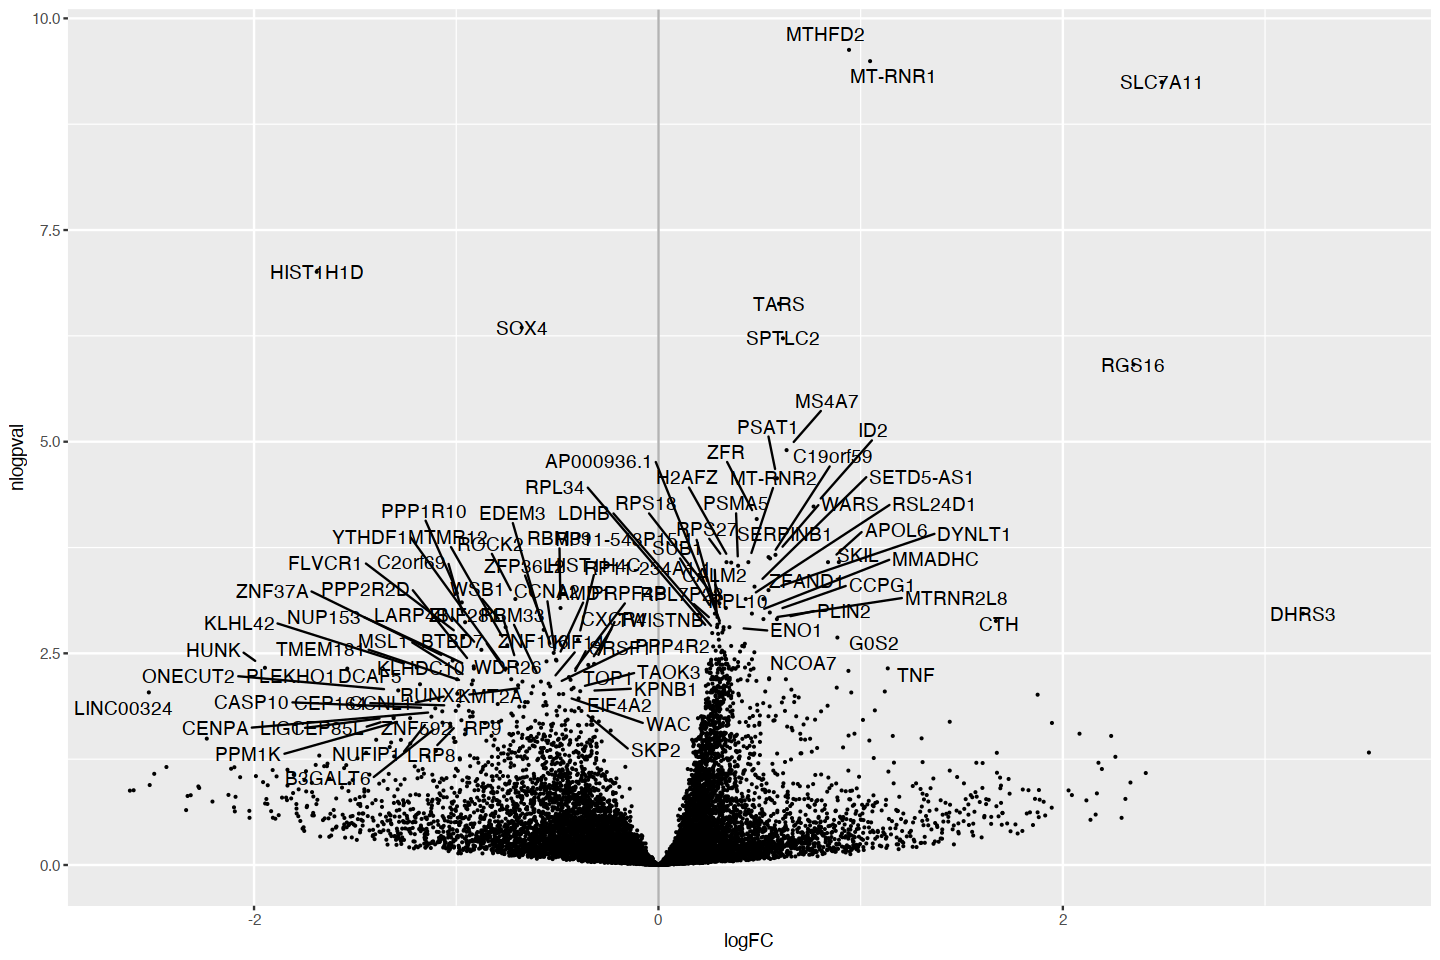

In [13]:
options(repr.plot.width=12, repr.plot.height=8)
ggplot(brq4, aes(x=logFC, y=nlogpval, label=label)) + 
geom_point(size=0.1) + geom_text_repel(point.padding = 1, max.overlaps=50) +
geom_vline(xintercept=0, alpha=0.3)

Warning message:
"ggrepel: 163 unlabeled data points (too many overlaps). Consider increasing max.overlaps"


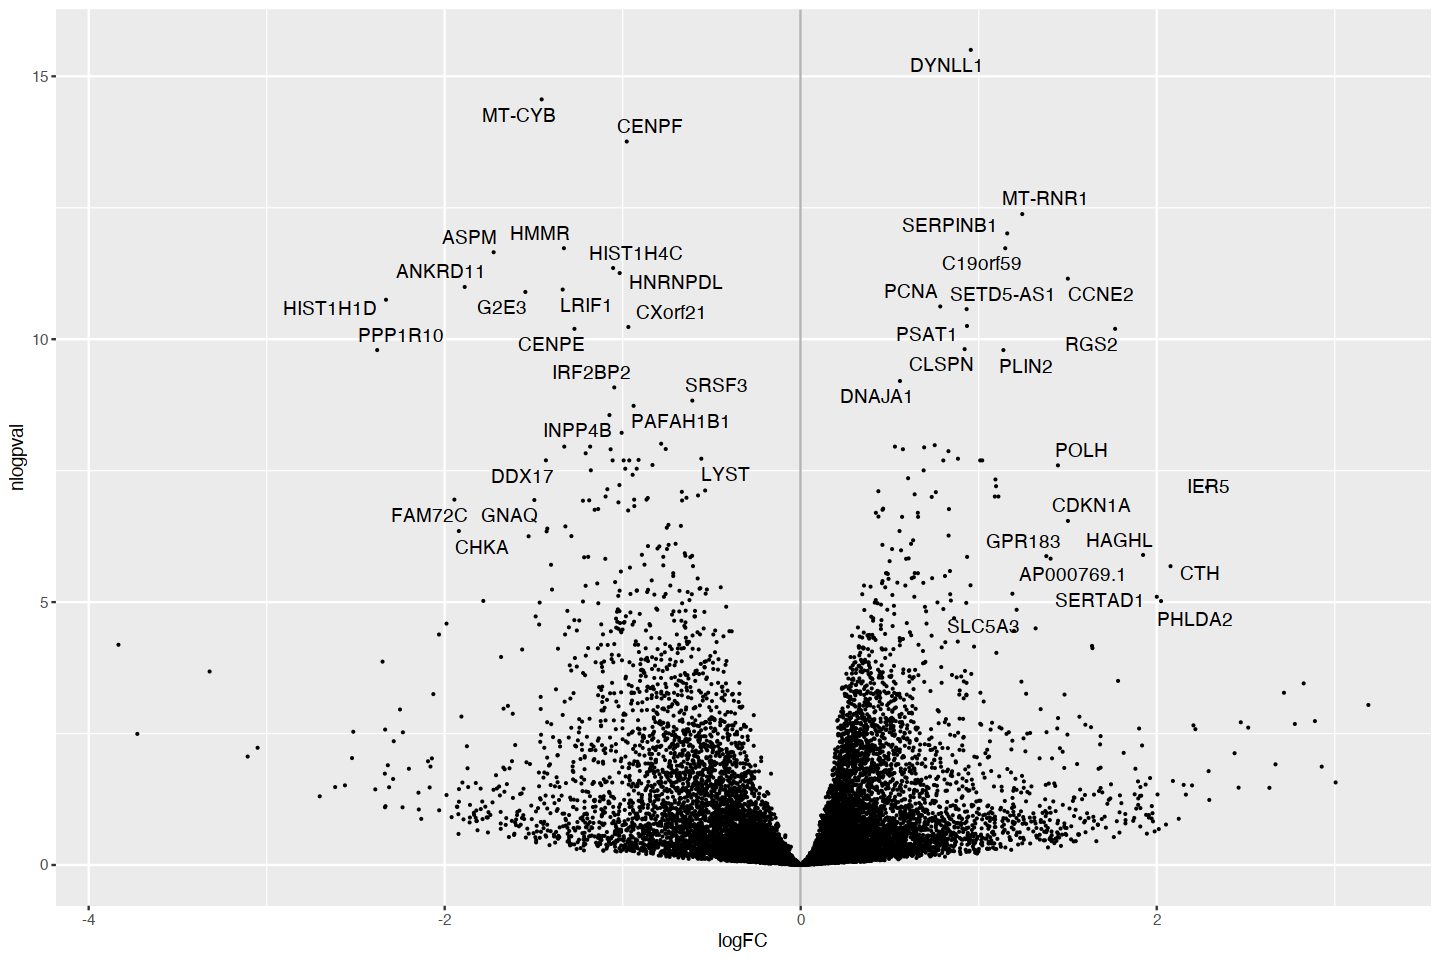

In [13]:
options(repr.plot.width=12, repr.plot.height=8)
ggplot(brq8, aes(x=logFC, y=nlogpval, label=label)) + 
geom_point(size=0.1) + geom_text_repel(point.padding = 1) +
geom_vline(xintercept=0, alpha=0.3)

Warning message:
"ggrepel: 172 unlabeled data points (too many overlaps). Consider increasing max.overlaps"


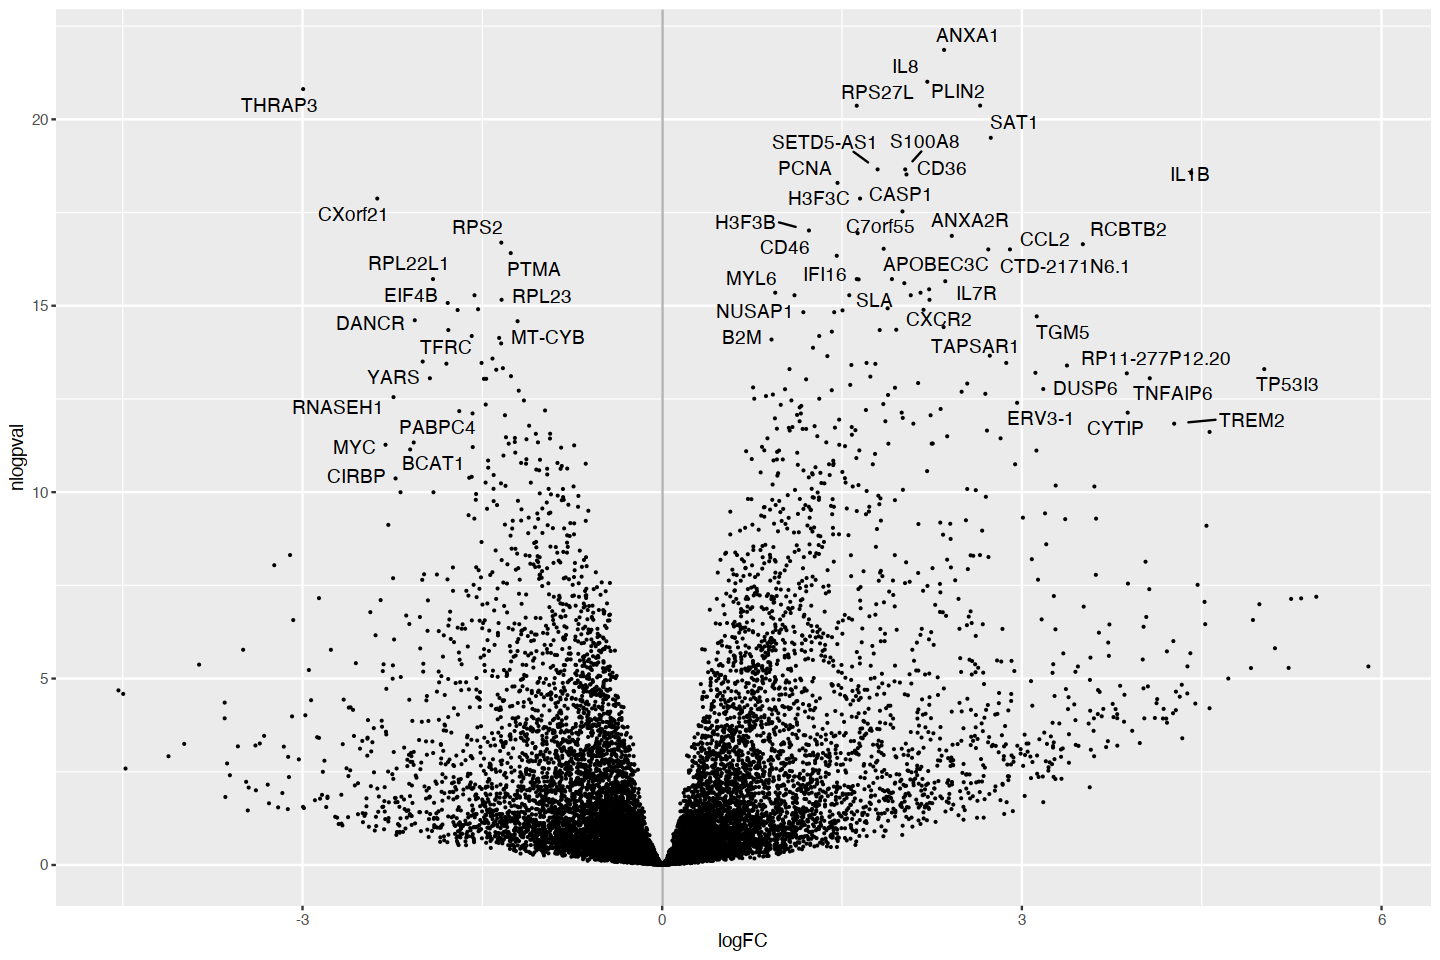

In [190]:
options(repr.plot.width=12, repr.plot.height=8)
ggplot(brq24, aes(x=logFC, y=nlogpval, label=label)) + 
geom_point(size=0.1) + geom_text_repel(point.padding = 1) +
geom_vline(xintercept=0, alpha=0.3)

Warning message:
"ggrepel: 135 unlabeled data points (too many overlaps). Consider increasing max.overlaps"


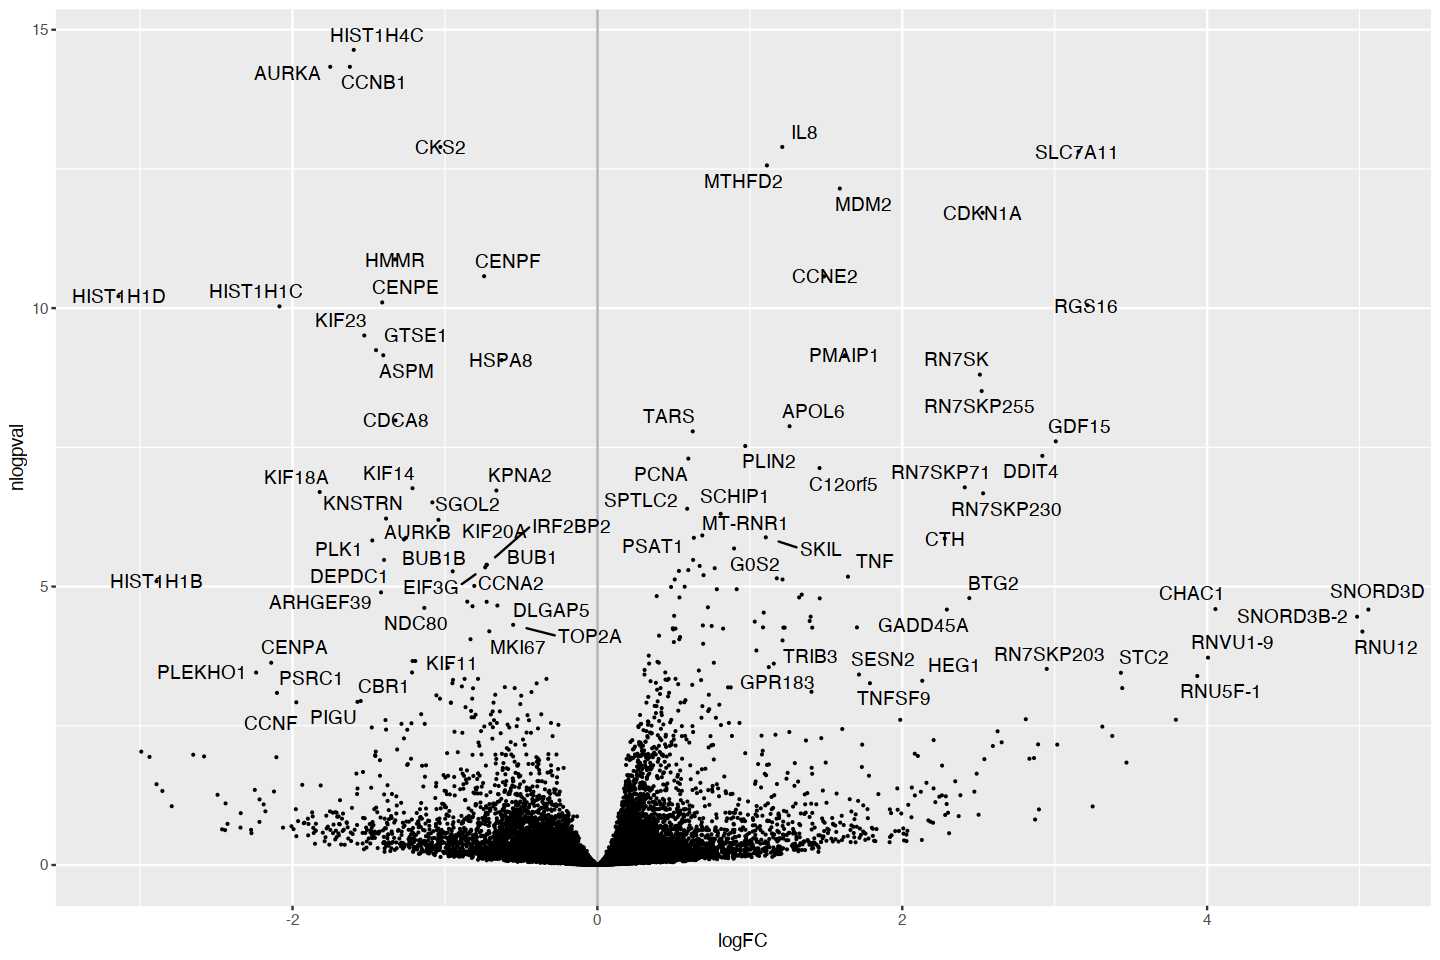

In [14]:
options(repr.plot.width=12, repr.plot.height=8)
ggplot(hu4, aes(x=logFC, y=nlogpval, label=label)) + 
geom_point(size=0.1) + geom_text_repel(point.padding = 1) +
geom_vline(xintercept=0, alpha=0.3)

Warning message:
"ggrepel: 145 unlabeled data points (too many overlaps). Consider increasing max.overlaps"


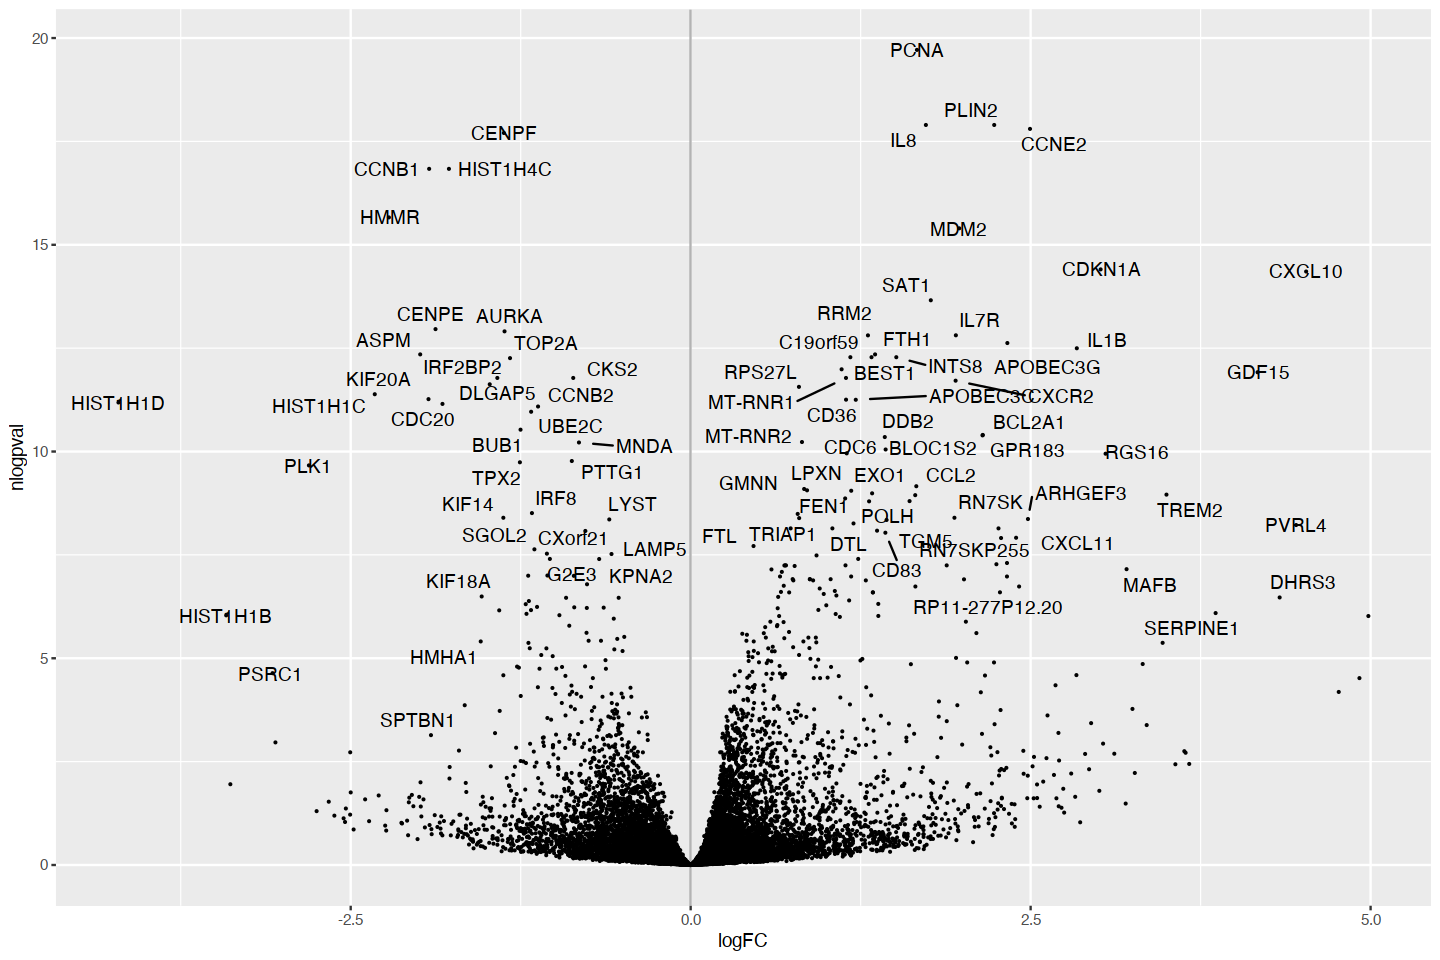

In [15]:
options(repr.plot.width=12, repr.plot.height=8)
ggplot(hu8, aes(x=logFC, y=nlogpval, label=label)) + 
geom_point(size=0.1) + geom_text_repel(point.padding = 1) +
geom_vline(xintercept=0, alpha=0.3)

In [20]:
z = rownames(subset(hu4, (logFC > 1) & (adj.P.Val < 0.05)))
z[order(z)]

[1] "AC005076.5"   "AC007386.2"   "AC231657.1"   "APOBEC3G"     "APOL6"       
  [6] "ARAP2"        "ARHGEF3"      "ATF3"         "BCL2A1"       "BIK"         
 [11] "BTG2"         "C12orf5"      "C14orf182"    "CAPRIN2"      "CCNE2"       
 [16] "CDKN1A"       "CDKN2B"       "CEBPB"        "CHAC1"        "CTB-61M7.2"  
 [21] "CTH"          "DDIT4"        "DHRS3"        "E2F7"         "EGR1"        
 [26] "ENO1-AS1"     "EPS8"         "FANCE"        "FAS"          "FCAR"        
 [31] "G0S2"         "GADD45A"      "GDF15"        "GPR183"       "GPR35"       
 [36] "GRB10"        "HEG1"         "IER5"         "IL1B"         "IL8"         
 [41] "INTS9"        "KB-1732A1.1"  "KBTBD11"      "KDM7A"        "KLF10"       
 [46] "LACC1"        "LENG8-AS1"    "LINC-PINT"    "LINC00662"    "MAFB"        
 [51] "MARCH3"       "MDM2"         "MTHFD2"       "NCOA7"        "PLK2"        
 [56] "PMAIP1"       "PPM1D"        "PSPH"         "PTCH2"        "PVRL4"       
 [61] "PXK"          "RAD51AP2"     "RELL1"        "RGS16"        "RHOH"        
 [66] "RN7SK"        "RN7SKP203"    "RN7SKP230"    "RN7SKP255"    "RN7SKP36"    
 [71] "RN7SKP71"     "RN7SKP80"     "RN7SKP9"      "RND3"         "RNU1-3"      
 [76] "RNU12"        "RNU5F-1"      "RNVU1-14"     "RNVU1-15"     "RNVU1-9"     
 [81] "RP11-611O2.1" "RP11-611O2.5" "RP11-666A8.7" "RP11-76E17.3" "RP11-849H4.2"
 [86] "RP4-536B24.4" "SESN1"        "SESN2"        "SKIL"         "SLC7A11"     
 [91] "SLC7A11-AS1"  "SLFN5"        "SNORD3A"      "SNORD3B-2"    "SNORD3C"     
 [96] "SNORD3D"      "STC2"         "STOX2"        "TAGAP"        "TGFA"        
[101] "TNF"          "TNFSF4"       "TNFSF9"       "TREM1"        "TREM2"       
[106] "TRIB3"        "XAF1"

In [29]:
interesting_genes = c("SLC7A11", "MTHFD2", "CTH", "CHAC1", "ATF4", "DDIT4", "GDF15", "CDKN1A", "CCNE2", "FCAR", "CEBPB",
                      "IL1B", "IL8", "CXCL10", "EGR1", "FOS", "FOSB", "FOSL1", "JUN", "JUNB", "JUND",
                      "FOSL2", "CD36", "CXCR2", "IL7R", "LPXN", "MAFB", "ATF3", "DUSP1", "CD86",
                      "SLC15A3", "CD163", "SPI1", "PLIN2", "AIM2", "MS4A3", "CTSG", "MYB", "SOX4", "IRF8", "ZFP36L2")

In [ ]:
# SLC7A11 and MTHFD2 peak at 4h and drops after -- why?
# CTH and CHAC1 have a similar pattern - although CHAC1 is very low early so pval is not good 
# ATF4 drops at late timepoints, but also might have a slight peak very early
# DDIT4 has a similar pattern

# CDKN1A and CCNE2 go up 
# IL1B, IL8, CXCL10, GDF15 are all up (much faster in HU than BRQ) -- SASP markers! 
# IEGs: EGR1 is up in HU, but is down early in BRQ and only goes up by 24h
# FOS is lightly up but JUN/JUNB/JUND is undetectable

# https://www.frontiersin.org/articles/10.3389/fcell.2020.00498/full
# CD36, CXCR2, LPXN, CCL2, SLC15A3, and IL7R are up 2-4 fold at HU 8h but only gets there at BRQ 24h 
# CD163 is up in all the datasets but expression is very low early, so hard to detect
# MAFB and PLIN2 and AIM2 are up early d
# BTG2 up early https://www.nature.com/articles/ng.375
# CD14 and ITGAM undetectable

# MS4A3 and CTSG go down only at BRQ 24h
# SOX4 is moderately down at early timepoints
# MYB doesn't really change, really only for HU 1mM 
# IRF8 and ZFP36L2 drop gradually in all datasets 

Warning message:
"Removed 5 rows containing missing values (geom_point)."
Warning message:
"Removed 5 rows containing missing values (geom_text_repel)."
Warning message:
"Removed 5 rows containing missing values (geom_point)."
Warning message:
"Removed 5 rows containing missing values (geom_text_repel)."
Warning message:
"Removed 5 rows containing missing values (geom_point)."
Warning message:
"Removed 5 rows containing missing values (geom_text_repel)."
Warning message:
"Removed 5 rows containing missing values (geom_point)."
Warning message:
"Removed 5 rows containing missing values (geom_text_repel)."
Warning message:
"Removed 5 rows containing missing values (geom_point)."
Warning message:
"Removed 5 rows containing missing values (geom_text_repel)."
Warning message:
"ggrepel: 2 unlabeled data points (too many overlaps). Consider increasing max.overlaps"
Warning message:
"ggrepel: 7 unlabeled data points (too many overlaps). Consider increasing max.overlaps"
Warning message:
"ggrep

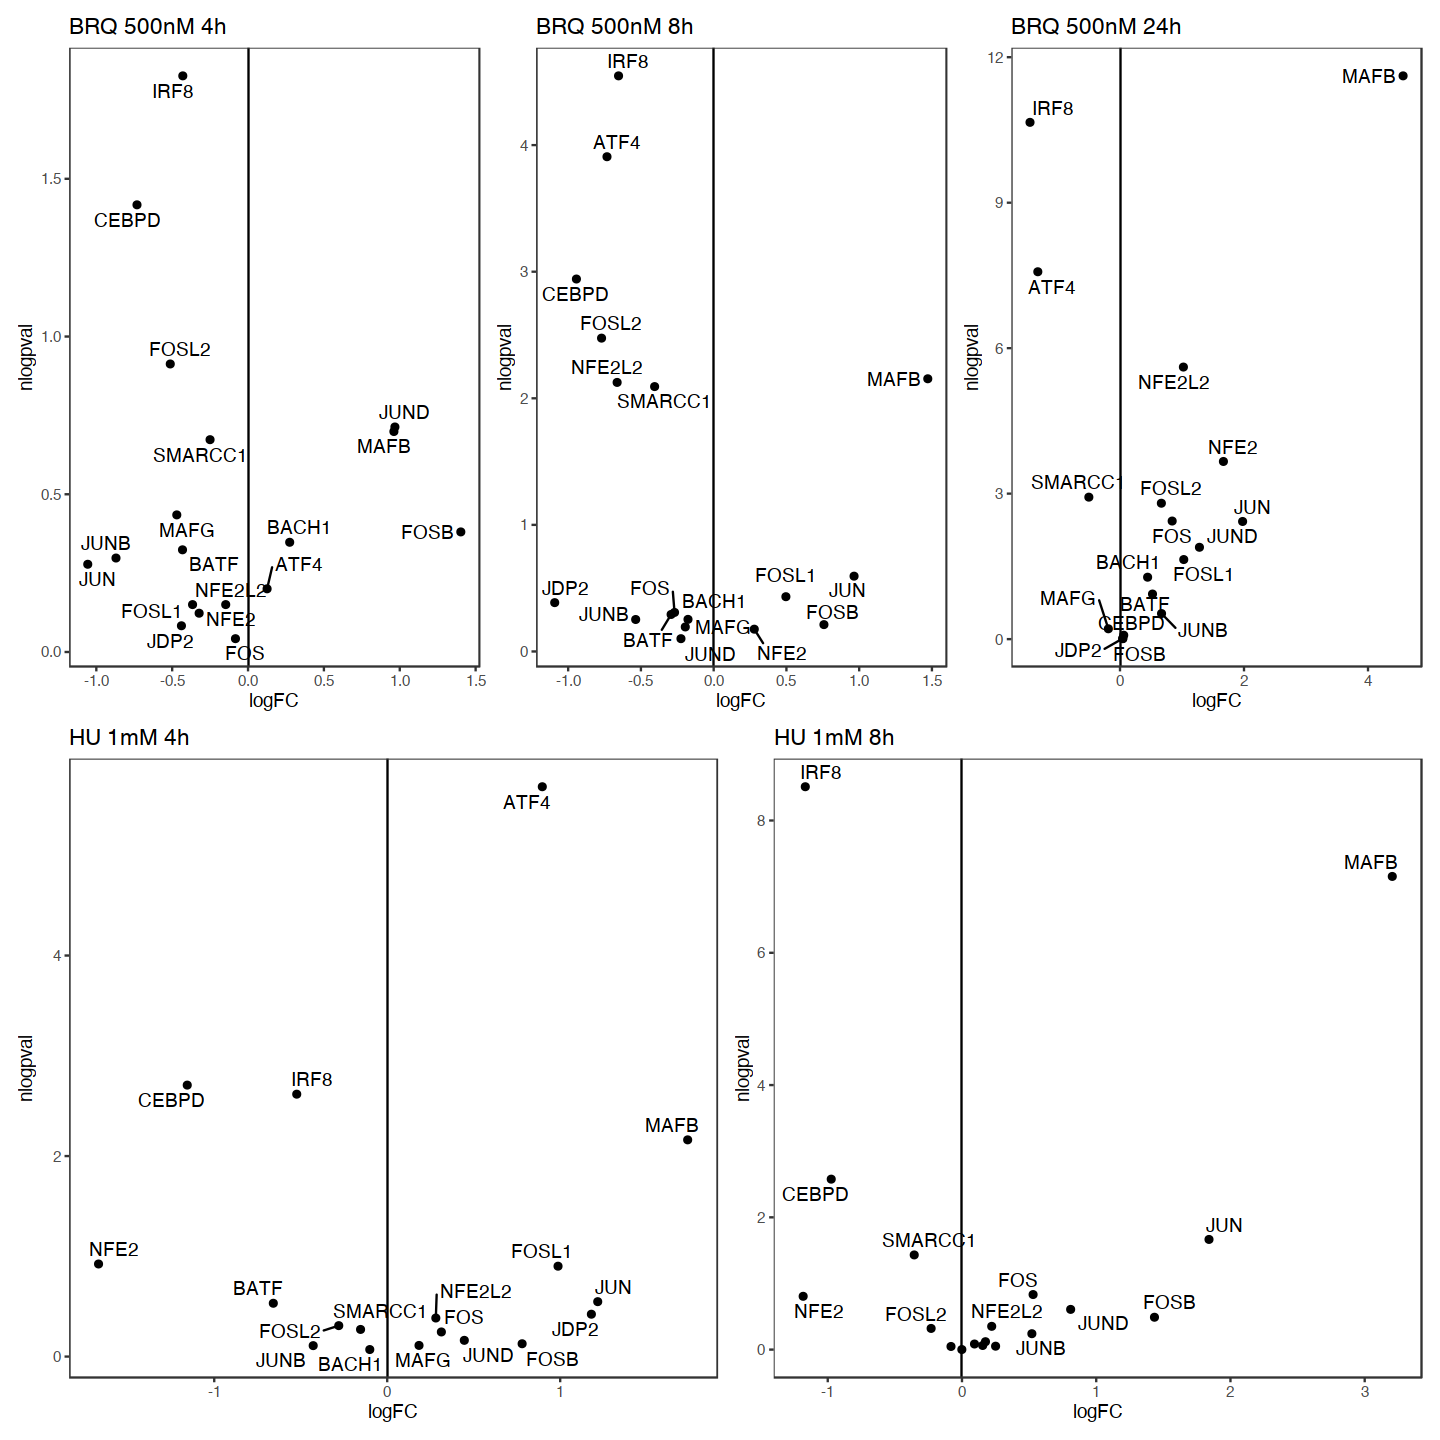

In [26]:
genes = c("FOSB", "BACH1", "BACH2", "JUND", "FOS", "SMARCC1", "FOSL1", "JUN", "FOSL2", "ATF4", "CEBPD",
"JUNB", "JDP2", "CIC", "NRL", "MAFG", "BATF", "MAFF", "NFE2L2", "MAFK", "MAFB", "NFE2")

g1 = ggplot(brq4[genes,], aes(x=logFC, y=nlogpval, label=rownames(brq4[genes,]))) +
geom_point() + geom_text_repel() + theme_bw() + geom_vline(xintercept=0) + ggtitle("BRQ 500nM 4h") +
theme(panel.grid.major=element_blank(), panel.grid.minor = element_blank())

g2 = ggplot(brq8[genes,], aes(x=logFC, y=nlogpval, label=rownames(brq8[genes,]))) +
geom_point() + geom_text_repel() + theme_bw() + geom_vline(xintercept=0) + ggtitle("BRQ 500nM 8h") +
theme(panel.grid.major=element_blank(), panel.grid.minor = element_blank())

g3 = ggplot(brq24[genes,], aes(x=logFC, y=nlogpval, label=rownames(brq24[genes,]))) +
geom_point() + geom_text_repel() + theme_bw() + geom_vline(xintercept=0) + ggtitle("BRQ 500nM 24h") +
theme(panel.grid.major=element_blank(), panel.grid.minor = element_blank())

g4 = ggplot(hu4[genes,], aes(x=logFC, y=nlogpval, label=rownames(hu4[genes,]))) +
geom_point() + geom_text_repel() + theme_bw() + geom_vline(xintercept=0) + ggtitle("HU 1mM 4h") +
theme(panel.grid.major=element_blank(), panel.grid.minor = element_blank())

g5 = ggplot(hu8[genes,], aes(x=logFC, y=nlogpval, label=rownames(hu8[genes,]))) +
geom_point() + geom_text_repel() + theme_bw() + geom_vline(xintercept=0) + ggtitle("HU 1mM 8h") +
theme(panel.grid.major=element_blank(), panel.grid.minor = element_blank())

(g1 + g2 + g3)/(g4 + g5)

Warning message:
"Removed 5 rows containing missing values (geom_point)."
Warning message:
"Removed 5 rows containing missing values (geom_text_repel)."
Warning message:
"Removed 5 rows containing missing values (geom_point)."
Warning message:
"Removed 5 rows containing missing values (geom_text_repel)."
Warning message:
"Removed 5 rows containing missing values (geom_point)."
Warning message:
"Removed 5 rows containing missing values (geom_text_repel)."
Warning message:
"ggrepel: 2 unlabeled data points (too many overlaps). Consider increasing max.overlaps"
Warning message:
"ggrepel: 7 unlabeled data points (too many overlaps). Consider increasing max.overlaps"
Warning message:
"Removed 5 rows containing missing values (geom_point)."
Warning message:
"Removed 5 rows containing missing values (geom_text_repel)."
Warning message:
"Removed 5 rows containing missing values (geom_point)."
Warning message:
"Removed 5 rows containing missing values (geom_text_repel)."
Warning message:
"Remov

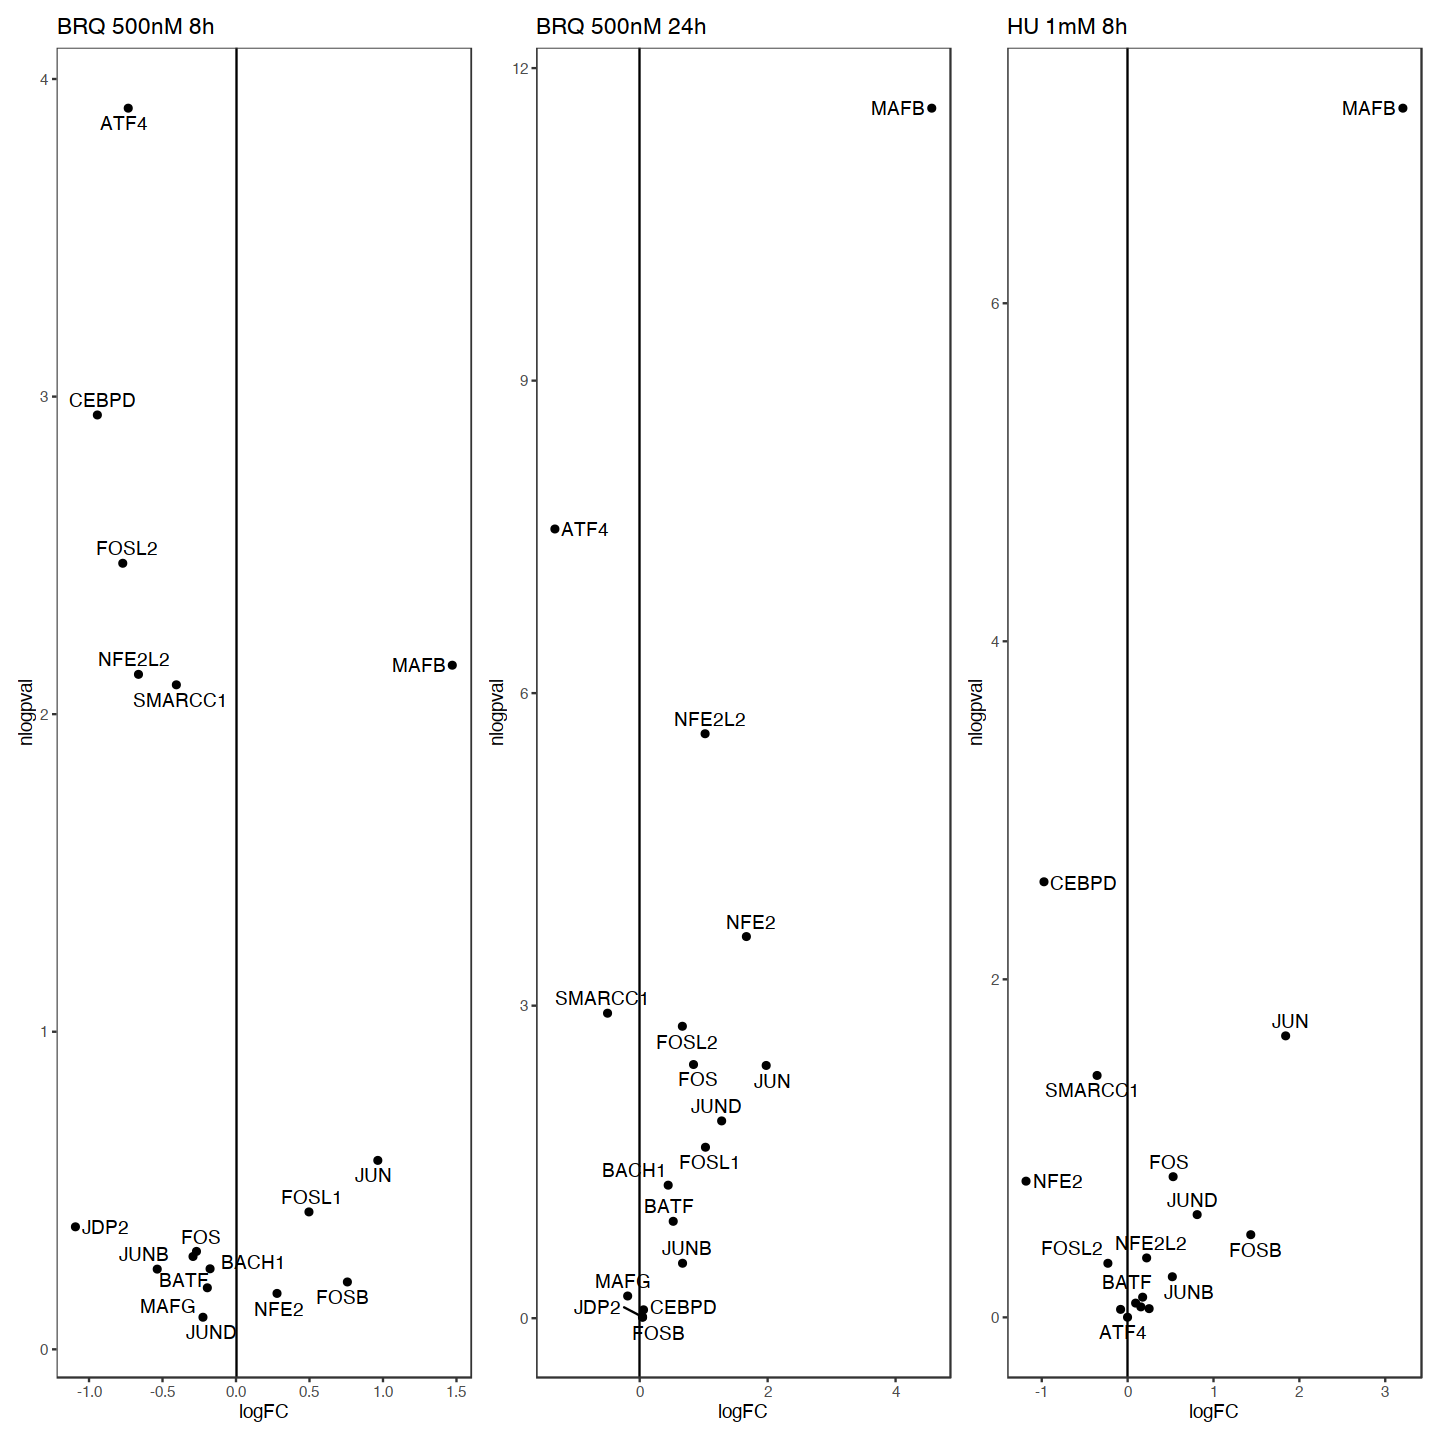

In [25]:
g2 + g3 + g5
ggsave("../../output/220315_thp1_mafb_4h.pdf", width=7, height=3)

In [38]:
gene = "NFE2"
brq4[gene,]
brq8[gene,]
brq24[gene,]
hu4[gene,]
hu8[gene,]

,logFC,AveExpr,t,P.Value,adj.P.Val,B,gene,nlogpval,label
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>
NFE2,-0.3223522,0.7096952,-0.7083032,0.4836663,0.7534863,-4.89959,NFE2,0.1229247,


,logFC,AveExpr,t,P.Value,adj.P.Val,B,gene,nlogpval,label
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>
NFE2,0.2790977,0.7096952,0.7243133,0.4739117,0.6667341,-5.306113,NFE2,0.1760473,


,logFC,AveExpr,t,P.Value,adj.P.Val,B,gene,nlogpval,label
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>
NFE2,1.667788,0.7096952,4.801246,3.217737e-05,0.000217106,2.353296,NFE2,3.663328,


,logFC,AveExpr,t,P.Value,adj.P.Val,B,gene,nlogpval,label
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>
NFE2,-1.668758,0.7096952,-2.71222,0.01047726,0.1192621,-2.738985,NFE2,0.9234976,


,logFC,AveExpr,t,P.Value,adj.P.Val,B,gene,nlogpval,label
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>
NFE2,-1.183141,0.7096952,-2.199975,0.03482412,0.1563469,-3.653679,NFE2,0.8059108,


In [32]:
norm_data[interesting_genes,]

,THP1_0h_rep1,THP1_0h_rep2,THP1_0h_rep3,THP1_0h_rep4,THP1_BRQ500nM_4h_rep1,THP1_BRQ500nM_4h_rep2,THP1_BRQ500nM_4h_rep3,THP1_BRQ500nM_4h_rep4,THP1_BRQ500nM_8h_rep1,THP1_BRQ500nM_8h_rep2,⋯,THP1_BRQ500nM_24h_rep2,THP1_BRQ500nM_24h_rep4,THP1_HU1mM_4h_rep1,THP1_HU1mM_4h_rep2,THP1_HU1mM_4h_rep3,THP1_HU1mM_4h_rep4,THP1_HU1mM_8h_rep1,THP1_HU1mM_8h_rep2,THP1_HU1mM_8h_rep3,THP1_HU1mM_8h_rep4
SLC7A11,2.46012644,2.53522485,3.06126350,2.5176537,5.1151454,4.99478058,5.4972526,4.9468682,2.8753692,3.4142345,⋯,2.8285371,2.2396634,5.7526286,5.8536616,5.9222134,5.7472221,4.82358546,4.3399055,4.5873686,4.42491426
MTHFD2,8.05413408,7.94953500,7.75966518,8.0255663,9.0265258,8.94867068,8.8152724,8.7607033,7.8579990,7.9106922,⋯,7.2133061,7.0815816,9.0428971,8.9936414,9.0730349,9.1099411,8.29650283,8.5205373,8.4747147,8.62664954
CTH,1.48709349,2.19573839,1.83887108,1.9493699,4.1770731,3.68936757,3.0494893,3.3919004,3.8054671,3.9034380,⋯,1.2825687,-0.0822647,4.3928637,3.9976101,4.0306851,4.1857663,3.53407884,3.5683827,4.3506079,3.87189465
CHAC1,-0.46043909,0.04046016,-3.44653114,-0.5866830,0.4521804,1.60483406,0.8331714,-0.6260215,0.1253474,-1.0320217,⋯,-1.0393594,0.5457665,3.3827394,2.8192729,2.5746204,2.7967240,0.07464722,0.8459166,-0.1366579,-0.05621243
ATF4,5.73502100,5.85015522,5.86408164,5.7952925,5.6354022,5.91928057,5.9131267,6.2639387,5.1617708,4.7067461,⋯,4.0050348,4.6431790,6.6445033,6.5955616,6.8457242,6.7604917,5.86761823,5.8308097,5.8665588,5.69570350
DDIT4,1.37606217,0.66849138,1.41144986,0.9982795,0.7416870,1.50174057,2.2375616,2.2615038,2.2806256,1.2899064,⋯,0.7261754,1.2131912,3.6759358,4.2055514,4.0574025,4.1503610,1.42828418,1.5828822,1.8108746,2.32845142
GDF15,1.77660010,2.00729330,1.30835636,1.8462764,1.6745728,1.87613608,0.8331714,1.4443679,1.7951988,2.0723149,⋯,4.5028987,4.9857807,4.0784824,4.9230208,4.6021011,5.1725909,6.04171333,5.8932223,5.8665588,5.77104205
CDKN1A,3.20793942,3.34921287,3.47233210,3.5671224,3.0101758,3.46109858,3.3456214,3.5598451,5.1212430,4.7597923,⋯,5.7181973,5.5537007,5.7288473,5.7644600,6.0868797,6.0862306,6.79041860,6.2104891,6.4310266,6.20431512
CCNE2,4.46691561,4.40120750,4.16079917,4.5991836,4.9116120,4.84488515,4.9055799,4.8069379,5.8507911,5.9859002,⋯,5.0137520,5.2494666,5.9089494,5.8129313,5.7890640,5.9868622,6.81611421,6.8277693,6.9793146,6.92868067
FCAR,1.48709349,1.38838346,1.30835636,1.8462764,2.1891460,1.91677807,1.3895647,1.5114820,1.7533786,2.3464899,⋯,3.7367446,3.7250902,2.0403472,2.9636628,2.5746204,2.7020871,3.83545956,3.7334419,4.0446718,3.35882507


In [235]:
interesting_genes = c("SLC7A11", "MTHFD2", "CTH", "CHAC1", "ATF4", "DDIT4", "GDF15", "CDKN1A", "CCNE2",
                      "IL1B", "IL8", "CXCL10", "EGR1", "FOS", "FOSB", "FOSL1", "JUN", "JUNB", "JUND",
                      "FOSL2", "CD36", "CXCR2", "IL7R", "LPXN", "MAFB", "ATF3", "DUSP1", "CD86",
                      "SLC15A3", "CD163", "SPI1", "PLIN2", "AIM2", "MS4A3", "CTSG", "MYB", "SOX4", "IRF8", "ZFP36L2")

Warning message:
"The input is a data frame, convert it to a matrix."


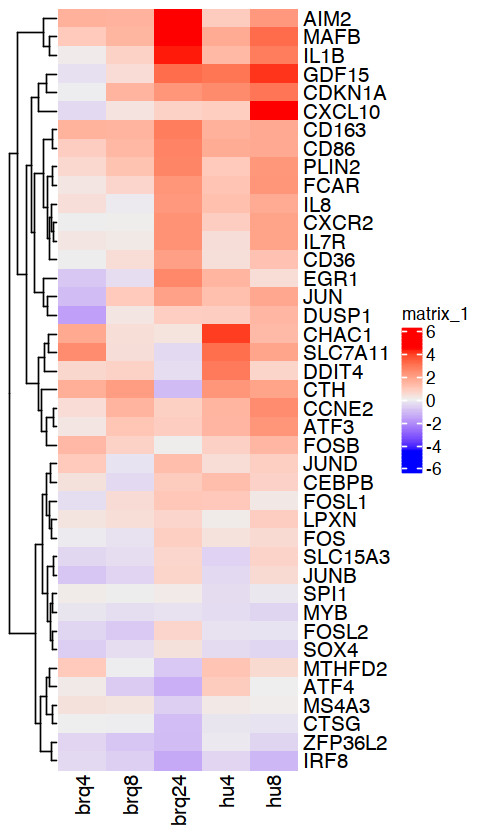

In [30]:
genes = data.frame(cbind(brq4[interesting_genes, "logFC"], brq8[interesting_genes, "logFC"], 
                         brq24[interesting_genes, "logFC"],
                         hu4[interesting_genes, "logFC"], hu8[interesting_genes, "logFC"]))
rownames(genes) = interesting_genes
colnames(genes) = c("brq4", "brq8", "brq24", "hu4", "hu8")

options(repr.plot.width=4, repr.plot.height=7)
Heatmap(genes, cluster_columns=F, width=4)

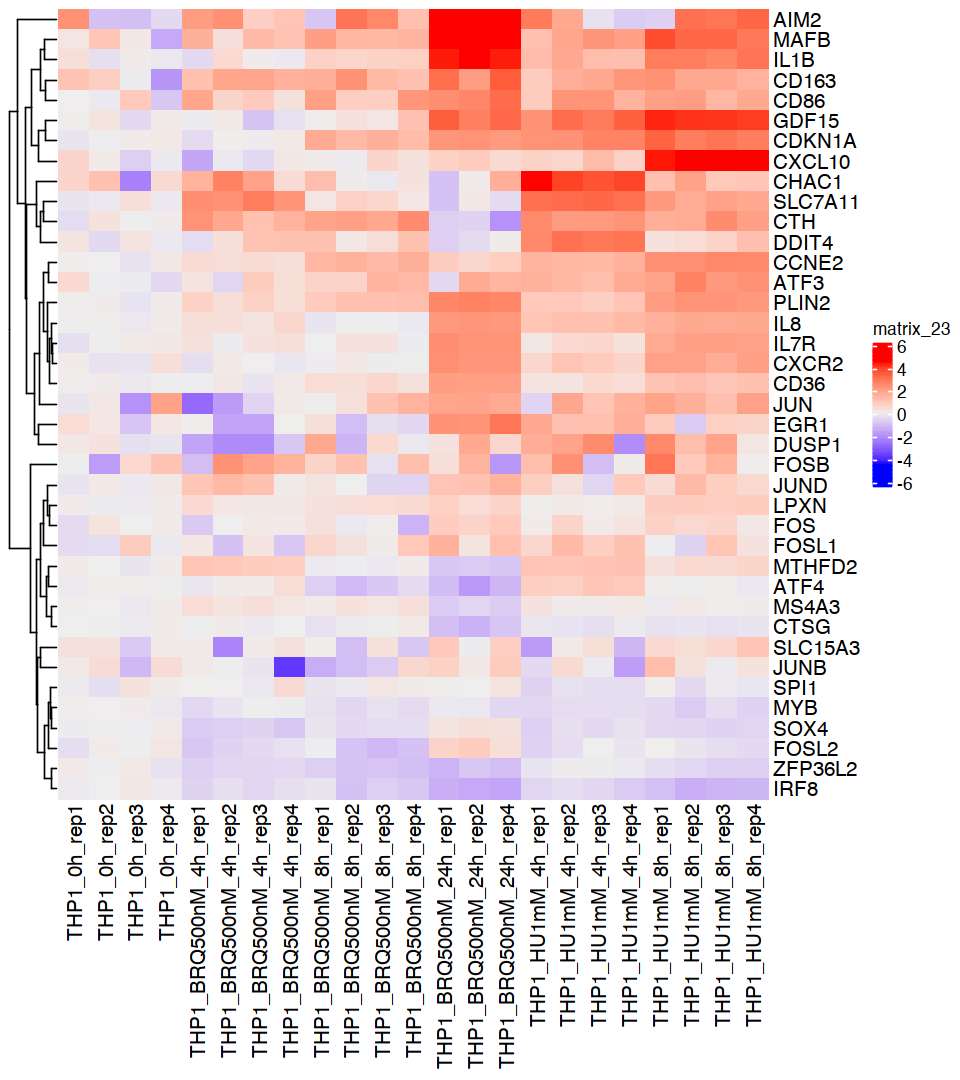

In [237]:
options(repr.plot.width=8, repr.plot.height=9)
Heatmap(norm_data[interesting_genes,] - apply(norm_data[interesting_genes,1:4],1,mean), cluster_columns=F)


In [243]:
tp4 = data.frame(cbind(brq4[,"logFC"], hu4[rownames(brq4),"logFC"]))
rownames(tp4) = rownames(brq4)
colnames(tp4) = c("brq4", "hu4")

tp4$label = rownames(tp4)
tp4[apply(tp4[,1:2],1,function(x) max(abs(x)) < 1.8),]$label = ""
head(tp4)

,brq4,hu4,label
,<dbl>,<dbl>,<chr>
MTHFD2,0.9425064,1.1122187,
MT-RNR1,1.0467303,0.6881200,
SLC7A11,2.4888704,3.1566858,SLC7A11
TARS,0.5963798,0.6253301,
SPTLC2,0.6156349,0.5887866,
RGS16,2.3493122,3.2147850,RGS16


Warning message:
"ggrepel: 147 unlabeled data points (too many overlaps). Consider increasing max.overlaps"


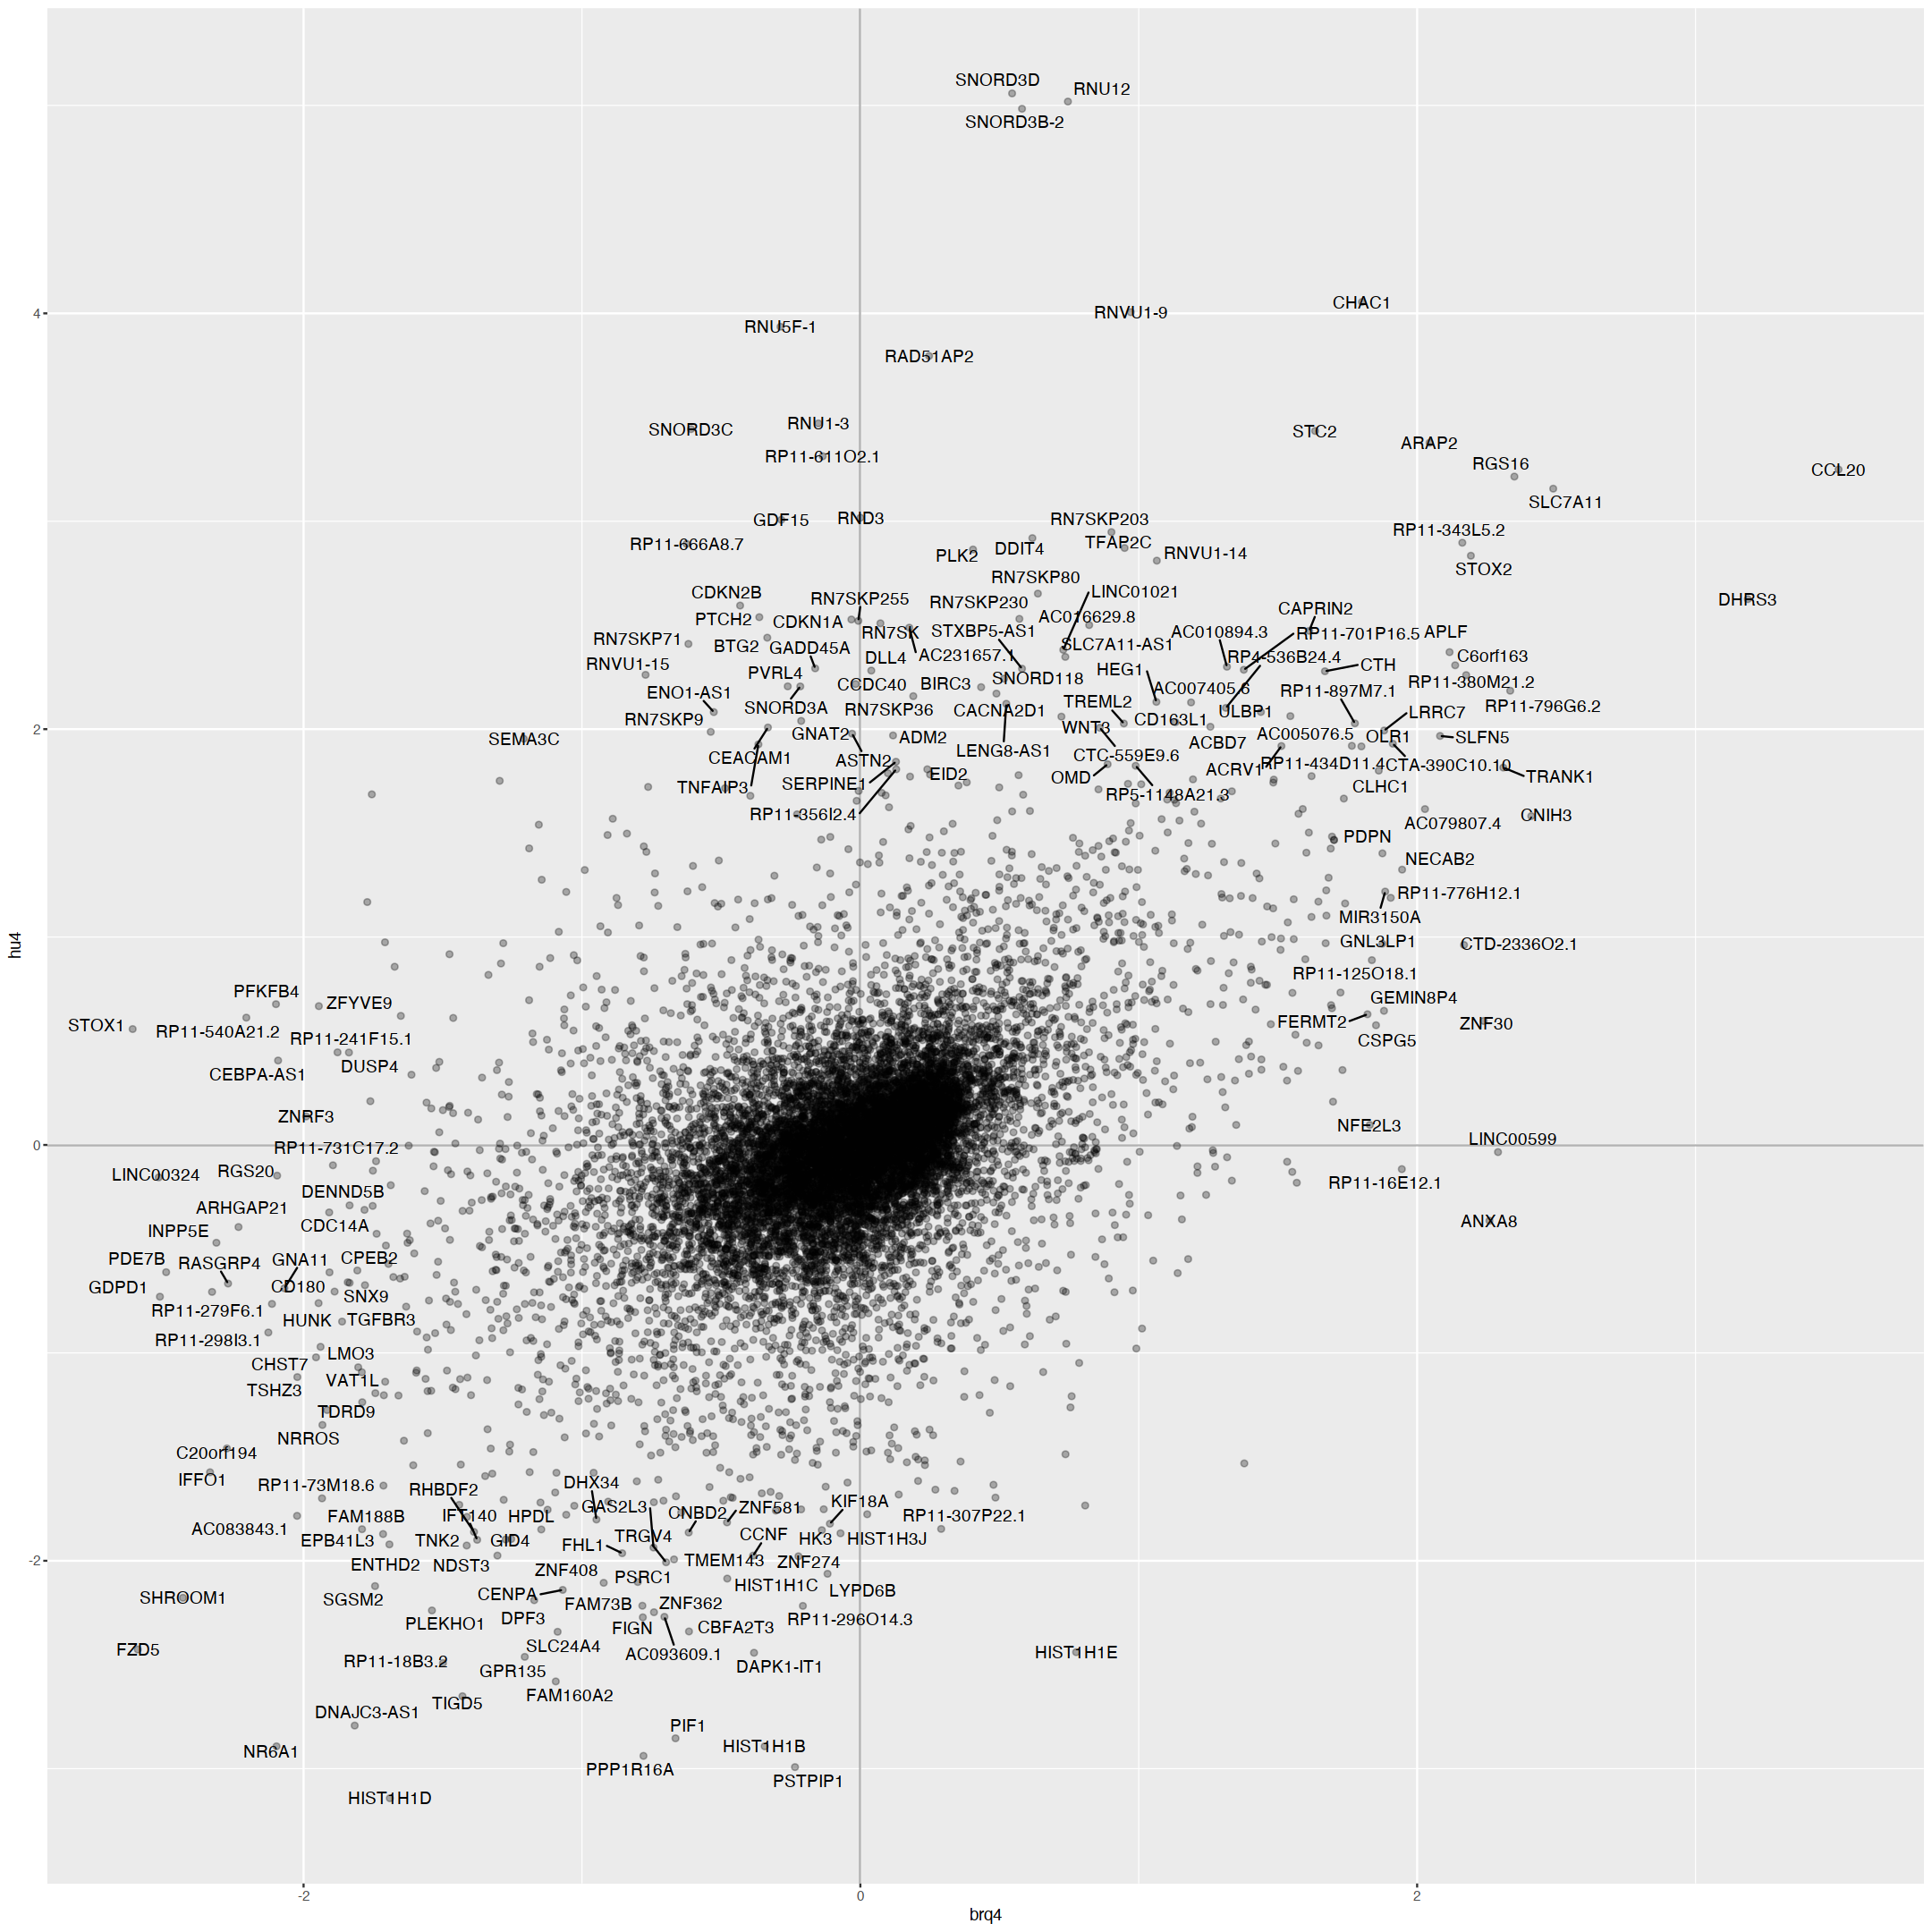

In [244]:
options(repr.plot.height=18, repr.plot.width=18)
ggplot(tp4, aes(x=brq4, y=hu4, label=label)) + geom_point(alpha=0.3) + 
geom_text_repel() + geom_hline(yintercept=0, alpha=0.3) + geom_vline(xintercept=0, alpha=0.3)